In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
loan_dataset = pd.read_csv('/content/train_u6lujuX_CVtuZ9i (1).csv')

In [ ]:
loan_dataset.shape

(614, 13)

In [ ]:
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
loan_dataset.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
loan_dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
loan_dataset = loan_dataset.dropna() # as no. of missing data is not much--> dropped

In [ ]:
loan_dataset.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
# Label Encoding
loan_dataset.replace({'Loan_Status' : {'N':0,'Y':1}},inplace=True)

/tmp/ipython-input-4178392151.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_dataset.replace({'Loan_Status' : {'N':0,'Y':1}},inplace=True)


In [ ]:
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [ ]:
loan_dataset['Dependents'].value_counts()

,count
Dependents,
0,274
2,85
1,80
3+,41


In [ ]:
loan_dataset['Dependents'] = loan_dataset['Dependents'].replace('3+', '4')

In [ ]:
loan_dataset['Dependents'] = loan_dataset['Dependents'].astype(int)
print(loan_dataset.dtypes)

Loan_ID               object
Gender                object
Married               object
Dependents             int64
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status            int64
dtype: object


In [ ]:
#converting categorials to numerical
loan_dataset.replace({'Gender' : {'Male':0,'Female' :1}},inplace = True)
loan_dataset.replace({'Married' : {'Yes' :0, 'No':1}},inplace = True)
loan_dataset.replace({'Education' : {'Graduate' :0, 'Not Graduate':1}},inplace = True)
loan_dataset.replace({'Self_Employed' : {'Yes' :0, 'No':1}},inplace = True)
loan_dataset.replace({'Property_Area' : {'Rural' :0, 'Urban':1, 'Semiurban':2}},inplace = True)

/tmp/ipython-input-4006193503.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_dataset.replace({'Gender' : {'Male':0,'Female' :1}},inplace = True)
/tmp/ipython-input-4006193503.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_dataset.replace({'Married' : {'Yes' :0, 'No':1}},inplace = True)
/tmp/ipython-input-4006193503.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in

In [ ]:
#loan_dataset.head()
print(loan_dataset)

      Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
1    LP001003       0        0           1          0              1   
2    LP001005       0        0           0          0              0   
3    LP001006       0        0           0          1              1   
4    LP001008       0        1           0          0              1   
5    LP001011       0        0           2          0              0   
..        ...     ...      ...         ...        ...            ...   
609  LP002978       1        1           0          0              1   
610  LP002979       0        0           4          0              1   
611  LP002983       0        0           1          0              1   
612  LP002984       0        0           2          0              1   
613  LP002990       1        1           0          0              0   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
1               4583             1508.0       128.0           

In [ ]:
loan_dataset = loan_dataset.drop('Loan_ID',axis = 1)

Data Visualization

In [ ]:
corr = loan_dataset.corr()

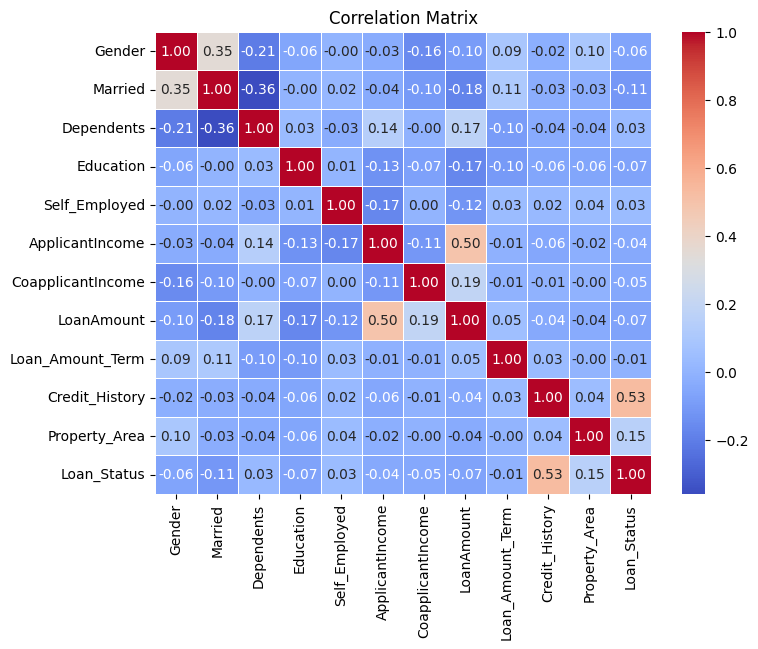

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

<Axes: xlabel='Education', ylabel='count'>

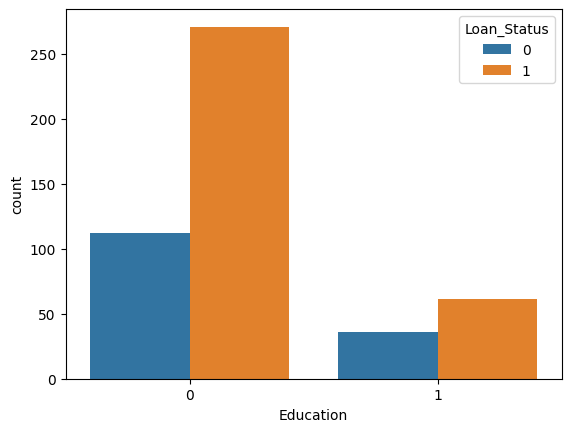

In [ ]:
#Education vs Loan
sns.countplot(x = 'Education',hue = 'Loan_Status',data = loan_dataset)

<Axes: xlabel='Married', ylabel='count'>

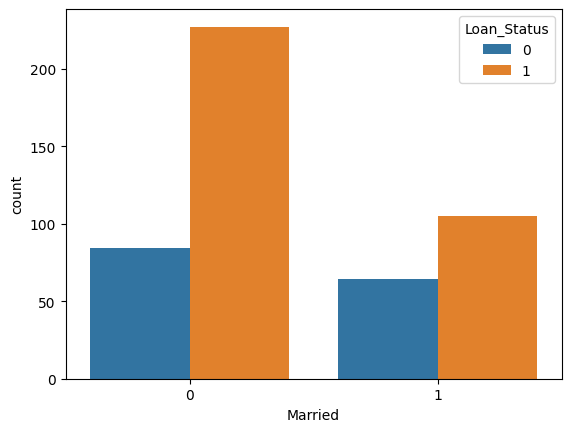

In [ ]:
# Marital Status and Loan
sns.countplot(x = 'Married',hue = 'Loan_Status',data = loan_dataset)

<Axes: xlabel='Loan_Status', ylabel='ApplicantIncome'>

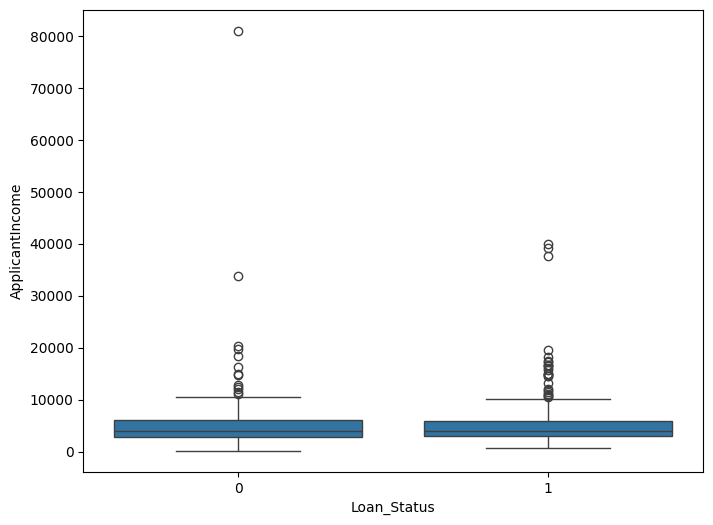

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=loan_dataset)

In [ ]:
loan_dataset.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,0,0,1,0,1,4583,1508.0,128.0,360.0,1.0,0,0
2,0,0,0,0,0,3000,0.0,66.0,360.0,1.0,1,1
3,0,0,0,1,1,2583,2358.0,120.0,360.0,1.0,1,1
4,0,1,0,0,1,6000,0.0,141.0,360.0,1.0,1,1
5,0,0,2,0,0,5417,4196.0,267.0,360.0,1.0,1,1


Training Test Data

In [ ]:
x = loan_dataset.drop(columns=['Loan_Status'],axis = 1)
y = loan_dataset['Loan_Status']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

#Model Training And Evaluation


Model 1:-> SVM

In [ ]:
Model1 = svm.SVC(kernel='linear')

In [ ]:
Model1.fit(x_train,y_train)

SVC(kernel='linear')

In [ ]:
y_pred1 = Model1.predict(x_test)

In [ ]:
#Training Accuracy
x_train_predict = Model1.predict(x_train)
train_predict = accuracy_score(x_train_predict,y_train)
print(train_predict)

0.7682291666666666


In [ ]:
#Test Accuracy
x_test_predict = Model1.predict(x_test)
test_predict = accuracy_score(x_test_predict,y_test)
print(test_predict)

0.7604166666666666


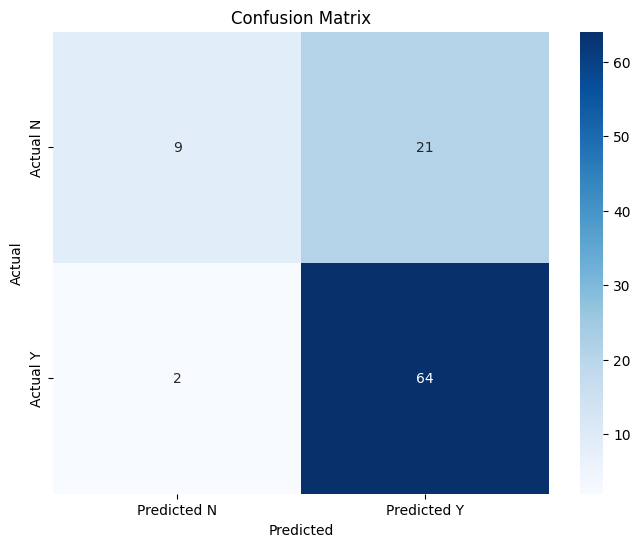

In [ ]:
cm = confusion_matrix(y_test, y_pred1)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted N', 'Predicted Y'], yticklabels=['Actual N', 'Actual Y'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Model 2:-> Logistic Regression

In [ ]:
Model2 = LogisticRegression()

Model2.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred2 = Model2.predict(x_test)

In [ ]:
x_train_predict = Model2.predict(x_train)
train_predict = accuracy_score(x_train_predict,y_train)
print(train_predict)

0.7864583333333334


In [ ]:
x_test_predict = Model2.predict(x_test)
test_predict = accuracy_score(x_test_predict,y_test)
print(test_predict)

0.7708333333333334


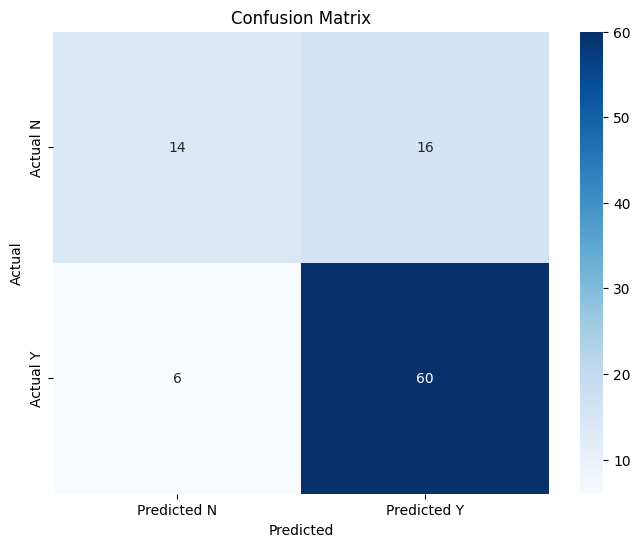

In [ ]:
cm = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted N', 'Predicted Y'], yticklabels=['Actual N', 'Actual Y'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Model 3:-> Random Forest Classifier

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
Model3 = RandomForestClassifier(random_state=42)

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],  # None means no limit
    'min_samples_leaf': [1, 2, 4]
}

In [ ]:
grid_search = GridSearchCV(estimator=Model3, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

In [ ]:
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [ ]:
print("Best hyperparameters: ", grid_search.best_params_)
print("Best cross-validation accuracy: ", grid_search.best_score_)

Best hyperparameters:  {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 50}
Best cross-validation accuracy:  0.7994531784005469


In [ ]:
y_pred3 = grid_search.predict(x_test)

In [ ]:
x_train_predict = grid_search.predict(x_train)
train_predict = accuracy_score(x_train_predict,y_train)
print(train_predict)

0.8307291666666666


In [ ]:
x_test_predict = grid_search.predict(x_test)
test_predict = accuracy_score(x_test_predict,y_test)
print(test_predict)

0.8333333333333334


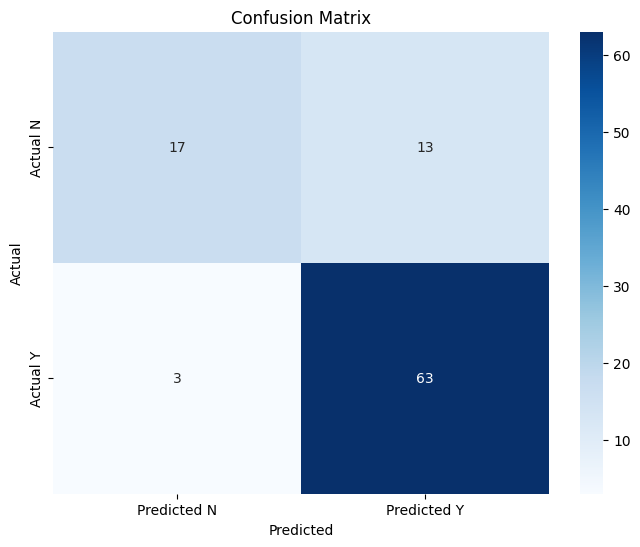

In [ ]:
cm = confusion_matrix(y_test, y_pred3)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted N', 'Predicted Y'], yticklabels=['Actual N', 'Actual Y'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Model 4:-> XGB Classifier

In [ ]:
Model4 = XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,subsample=1,colsample_bytree=1,random_state=42,use_label_encoder=False,eval_metric="mlogloss" )

In [ ]:
Model4.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [16:13:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
              device=None, early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred4 = Model4.predict(x_test)

In [ ]:
x_train_predict = Model4.predict(x_train)
train_predict = accuracy_score(x_train_predict,y_train)
print(train_predict)

0.8932291666666666


In [ ]:
x_test_predict = Model4.predict(x_test)
test_predict = accuracy_score(x_test_predict,y_test)
print(test_predict)

0.84375


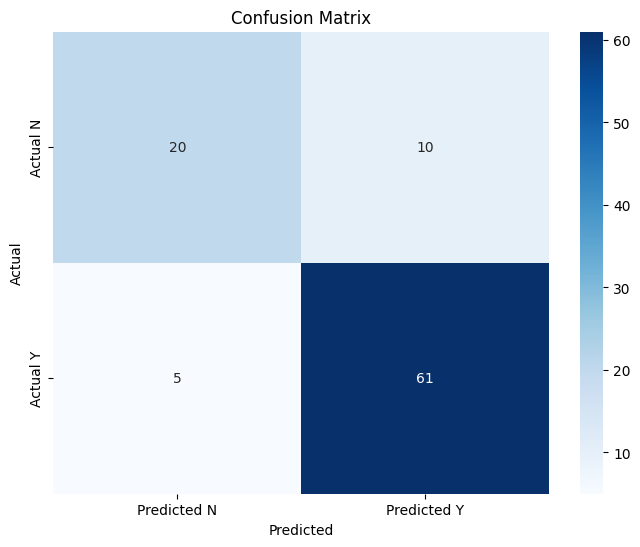

In [ ]:
cm = confusion_matrix(y_test, y_pred4)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted N', 'Predicted Y'], yticklabels=['Actual N', 'Actual Y'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()